# **Ejercicio 7: Aumento de datos**

El ejercicio pide aplicar transformaciones a los datos, volver a entrenar los modelos, discutir
los resultados y responder dos preguntas: por que un flip horizontal podria cambiar el
significado de una seña en vez de solo aumentar los datos, y que transformaciones si tienen
sentido para señas y cuales no.

El aumento se implemento como la **etapa 3 del pipeline** (`src/03_augmentation.py`), que genera
una sola vez el conjunto expandido y lo guarda en `03_tensores_aumentados.npz`. De esta forma
las tres familias de modelos reentrenan exactamente sobre los mismos datos y la comparacion
sigue siendo valida, cosa que no ocurriria si el aumento se aplicara con capas dentro de las
redes, ya que el Random Forest quedaria fuera.

Solo se aumento el conjunto de **entrenamiento**, que paso de 12,180 a 24,360 imagenes.
Validacion y prueba se dejaron intactas, porque transformarlas cambiaria las condiciones de
evaluacion y los resultados dejarian de ser comparables contra los modelos sin aumento.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier

import config as cfg
import modelado as m

datos = m.cargar_tensores()
datos_aug = m.cargar_tensores(cfg.RUTA_TENSORES_AUMENTADOS)

[ok] entrada (64, 64, 1)
[cargado]  tensores -> train 12180, val 2610, test 2610
[ok] entrada (64, 64, 1)
[cargado]  tensores -> train 24360, val 2610, test 2610


## **Transformaciones aplicadas**

| Transformacion | Rango | Por que si |
|---|---|---|
| Rotacion | +/- 10 grados | La mano nunca queda perfectamente alineada frente a la camara |
| Zoom | +/- 10% | Simula que la persona este mas cerca o mas lejos |
| Desplazamiento | +/- 10% | La mano no siempre queda centrada en el encuadre |
| Brillo | +/- 20% | Cubre condiciones de iluminacion distintas a las del estudio |
| Contraste | +/- 20% | Cubre diferencias de camara y de exposicion |

Los rangos se mantuvieron conservadores a proposito. Una rotacion fuerte deja de representar una
variacion realista de como alguien hace la seña frente a una camara, y ademas puede acercar
visualmente una letra a otra.

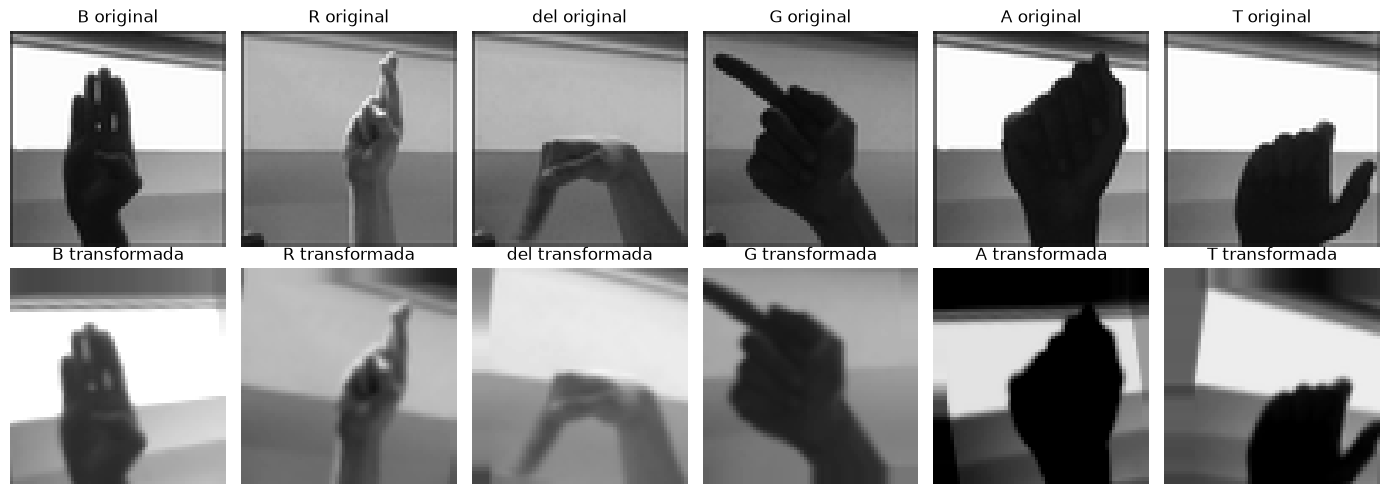

In [2]:
n = len(datos["x_train"])
rng = np.random.default_rng(cfg.SEMILLA)
muestras = rng.choice(n, size=6, replace=False)

fig, ejes = plt.subplots(2, 6, figsize=(14, 5))
for col, i in enumerate(muestras):
    letra = cfg.CLASES[datos_aug["y_train"][i]]
    ejes[0, col].imshow(datos_aug["x_train"][i].squeeze(), cmap="gray", vmin=0, vmax=1)
    ejes[0, col].set_title(f"{letra} original")
    ejes[1, col].imshow(datos_aug["x_train"][n + i].squeeze(), cmap="gray", vmin=0, vmax=1)
    ejes[1, col].set_title(f"{letra} transformada")
    for fila in (0, 1):
        ejes[fila, col].axis("off")

plt.tight_layout()
plt.show()

## **Por que no se aplico ningun espejo**

La pregunta del enunciado apunta a algo que distingue a este problema de una clasificacion de
objetos cualquiera. Cuando se aumenta un dataset de fotos de perros o de autos, un flip
horizontal es gratis: un auto visto en espejo sigue siendo un auto, y la etiqueta no cambia. En
las señas eso no se cumple.

Una seña del alfabeto ASL no es una figura simetrica, esta hecha con **una mano especifica**, y
su imagen espejo corresponde a la otra mano. Al aplicar un flip horizontal no se genera una
variacion nueva de la misma seña, sino la version zurda de esa seña, que es una pose que no
existe en ninguna parte del dataset, ya que todas las imagenes fueron capturadas con la misma
mano. Es por esto que el flip no aumenta los datos: introduce una distribucion distinta a la que
el modelo va a encontrar despues en validacion y en prueba.

Adicional, hay letras cuyo significado depende de la direccion hacia la que apunta la mano, de
tal forma que al reflejarlas la orientacion deja de corresponder con la letra que la etiqueta
dice que es. Bajo esta idea, el flip horizontal no solo agrega ruido sino que puede llegar a
introducir ejemplos mal etiquetados.

El flip vertical se descarta por una razon mas simple: produce una mano invertida, boca abajo,
que es una pose que nadie hace al comunicarse y que por lo tanto no aporta nada util.

Resumiendo cuales si y cuales no:

| Si tienen sentido | Por que |
|---|---|
| Rotacion leve, zoom, desplazamiento | Representan variaciones reales de como alguien se para frente a una camara |
| Brillo y contraste | Representan condiciones de iluminacion y camaras distintas |

| No tienen sentido | Por que |
|---|---|
| Flip horizontal | Cambia la mano con la que se hace la seña y puede alterar el significado |
| Flip vertical | Produce una pose que no ocurre en el uso real |
| Rotacion fuerte | Deja de ser una variacion realista y acerca visualmente unas letras a otras |

## **Reentrenamiento**

Se reentrena el mejor modelo de cada familia sobre el conjunto aumentado, manteniendo
exactamente la misma arquitectura e hiperparametros que tenian sin aumento, de forma que la
unica variable que cambia sea el conjunto de entrenamiento.

In [3]:
def construir_cnn_base(filtros=(32, 64, 64), densa=128):
    capas = [tf.keras.layers.Input(shape=cfg.FORMA_ENTRADA)]
    for f in filtros:
        capas += [
            tf.keras.layers.Conv2D(f, 3, activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(2),
        ]
    capas += [
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(densa, activation="relu"),
        tf.keras.layers.Dense(cfg.NUM_CLASES, activation="softmax"),
    ]
    return tf.keras.Sequential(capas, name="cnn_base_aug")


def construir_red_simple():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=cfg.FORMA_ENTRADA),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1024, activation="relu"),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(512, activation="relu"),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(cfg.NUM_CLASES, activation="softmax"),
    ], name="red_simple_aug")

### CNN base con aumento

In [4]:
cnn_aug = construir_cnn_base()
cnn_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

hist_cnn, t_cnn = m.entrenar(cnn_aug, datos_aug, batch_size=64)
res_cnn = m.evaluar(cnn_aug, datos_aug, "val")
reg_cnn = m.registrar("cnn_base_aug", cnn_aug, res_cnn, t_cnn,
                      historial=hist_cnn, batch_size=64,
                      notas="cnn_base reentrenada sobre el conjunto aumentado")

Epoch 1/30
381/381 - 27s - 70ms/step - accuracy: 0.3212 - loss: 2.3127 - val_accuracy: 0.6011 - val_loss: 1.2418
Epoch 2/30
381/381 - 26s - 67ms/step - accuracy: 0.6758 - loss: 1.0466 - val_accuracy: 0.7835 - val_loss: 0.6626
Epoch 3/30
381/381 - 27s - 71ms/step - accuracy: 0.7943 - loss: 0.6529 - val_accuracy: 0.8640 - val_loss: 0.4282
Epoch 4/30
381/381 - 27s - 71ms/step - accuracy: 0.8554 - loss: 0.4558 - val_accuracy: 0.8977 - val_loss: 0.3272
Epoch 5/30
381/381 - 26s - 68ms/step - accuracy: 0.8979 - loss: 0.3217 - val_accuracy: 0.9176 - val_loss: 0.2569
Epoch 6/30
381/381 - 25s - 65ms/step - accuracy: 0.9186 - loss: 0.2536 - val_accuracy: 0.9180 - val_loss: 0.2638
Epoch 7/30
381/381 - 26s - 67ms/step - accuracy: 0.9385 - loss: 0.1917 - val_accuracy: 0.9169 - val_loss: 0.2647
Epoch 8/30
381/381 - 26s - 67ms/step - accuracy: 0.9486 - loss: 0.1587 - val_accuracy: 0.9188 - val_loss: 0.2697
Epoch 9/30
381/381 - 26s - 70ms/step - accuracy: 0.9526 - loss: 0.1459 - val_accuracy: 0.9352 - 

### Red simple con aumento

In [5]:
red_aug = construir_red_simple()
red_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

hist_red, t_red = m.entrenar(red_aug, datos_aug, batch_size=128)
res_red = m.evaluar(red_aug, datos_aug, "val")
reg_red = m.registrar("red_simple_aug", red_aug, res_red, t_red,
                      historial=hist_red, batch_size=128,
                      notas="red_simple_v4 reentrenada sobre el conjunto aumentado")

Epoch 1/30
191/191 - 4s - 23ms/step - accuracy: 0.0632 - loss: 3.3310 - val_accuracy: 0.1195 - val_loss: 3.1678
Epoch 2/30
191/191 - 4s - 19ms/step - accuracy: 0.1079 - loss: 3.1568 - val_accuracy: 0.1782 - val_loss: 2.9685
Epoch 3/30
191/191 - 4s - 19ms/step - accuracy: 0.1393 - loss: 3.0168 - val_accuracy: 0.2065 - val_loss: 2.8091
Epoch 4/30
191/191 - 4s - 20ms/step - accuracy: 0.1642 - loss: 2.8922 - val_accuracy: 0.2479 - val_loss: 2.6352
Epoch 5/30
191/191 - 4s - 19ms/step - accuracy: 0.1885 - loss: 2.7837 - val_accuracy: 0.2808 - val_loss: 2.5179
Epoch 6/30
191/191 - 4s - 19ms/step - accuracy: 0.2067 - loss: 2.6893 - val_accuracy: 0.3046 - val_loss: 2.3951
Epoch 7/30
191/191 - 4s - 20ms/step - accuracy: 0.2284 - loss: 2.6019 - val_accuracy: 0.3326 - val_loss: 2.2855
Epoch 8/30
191/191 - 4s - 20ms/step - accuracy: 0.2443 - loss: 2.5191 - val_accuracy: 0.3816 - val_loss: 2.1953
Epoch 9/30
191/191 - 4s - 23ms/step - accuracy: 0.2607 - loss: 2.4620 - val_accuracy: 0.3935 - val_loss:

### Random Forest con aumento

In [6]:
rf_aug = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    max_features="sqrt",
    random_state=cfg.SEMILLA,
    n_jobs=-1,
)

t_rf = m.entrenar_clasico(rf_aug, datos_aug)
res_rf = m.evaluar(rf_aug, datos_aug, "val")
reg_rf = m.registrar("random_forest_aug", rf_aug, res_rf, t_rf,
                     notas="random_forest_v1 reentrenado sobre el conjunto aumentado")

[info] entrenado en 33.9 s
[info] accuracy en val: 0.9686
[guardado] random_forest_aug.joblib
[guardado] random_forest_aug.json


## **Comparacion: con aumento contra sin aumento**

Todas las cifras son sobre validacion, que es identica en ambos casos.

In [7]:
import json

def leer(nombre):
    return json.loads((cfg.DIR_RESULTADOS / f"{nombre}.json").read_text())

pares = [
    ("CNN base", "cnn_base", "cnn_base_aug"),
    ("Red simple", "red_simple_v4", "red_simple_aug"),
    ("Random Forest", "random_forest_v1", "random_forest_aug"),
]

filas = []
for familia, sin_aug, con_aug in pares:
    a, b = leer(sin_aug), leer(con_aug)
    filas.append({
        "familia": familia,
        "sin_aumento": round(a["accuracy"], 4),
        "con_aumento": round(b["accuracy"], 4),
        "diferencia": round(b["accuracy"] - a["accuracy"], 4),
        "seg_sin": a["tiempo_entrenamiento_seg"],
        "seg_con": b["tiempo_entrenamiento_seg"],
    })

pd.DataFrame(filas)

,familia,sin_aumento,con_aumento,diferencia,seg_sin,seg_con
0,CNN base,0.9590,0.9640,0.0050,428.1,517.4
1,Red simple,0.5812,0.6080,0.0268,113.6,117.8
2,Random Forest,0.9644,0.9686,0.0042,9.7,33.9


### **Discusion del aumento de datos**

Se probo el aumento de datos por medio de rotaciones, zoom, desplazamiento y ajustes en brillo y
contraste. No se aplico espejo, ya que, como se explico anteriormente, dada la naturaleza del
problema el hecho de reflejar la imagen puede cambiar totalmente el sentido de la seña, porque
la convierte en la version hecha con la otra mano.

Al analizar los resultados vemos que se experimento un ligero incremento en el rendimiento, y
cabe mencionar que ocurrio en todas las familias de modelos que se probaron, no en una sola.

| Familia | Sin aumento | Con aumento | Diferencia |
|---|---|---|---|
| CNN base | 0.9590 | 0.9640 | +0.0050 |
| Red simple | 0.5812 | 0.6080 | +0.0268 |
| Random Forest | 0.9644 | 0.9686 | +0.0042 |

En el caso de la CNN el incremento fue de 0.0050, que es algo despreciable hasta cierto nivel;
no obstante, no podemos descartar el hecho de que al aumentar los datos obtuvimos mejores
resultados. La red simple paso de 0.5812 a 0.6080 y el Random Forest de 0.9644 a 0.9686.

Dicho esto, considero que lo relevante no es la magnitud sino la consistencia: las tres familias
mejoraron, y ninguna empeoro. Bajo esta idea, aunque las diferencias sean pequeñas, el aumento
de datos no perjudico a ningun modelo, de tal forma que se puede mantener sin costo en la
calidad del resultado.